In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import time
import numpy as np
from tqdm import tqdm, trange
from shapely.geometry import Point, MultiPoint
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import pearsonr
from matplotlib_scalebar.scalebar import ScaleBar
#from shapely.ops import cascaded_union, unary_union
import utils
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
print(os.getcwd())  # 현재 작업 디렉터리 출력


/Users/jin/Downloads/2SFCA


In [3]:
parks = gpd.read_file('./data/도시숲전체_면_서울_최종_중분류.shp') # nas greenspace.shp

In [4]:
pop = pd.read_csv('./data/LOCAL_PEOPLE_20250509.csv', encoding='cp949')
pop

,"?""기준일ID""",시간대구분,행정동코드,집계구코드,총생활인구수,남자0세부터9세생활인구수,남자10세부터14세생활인구수,남자15세부터19세생활인구수,남자20세부터24세생활인구수,남자25세부터29세생활인구수,...,여자25세부터29세생활인구수,여자30세부터34세생활인구수,여자35세부터39세생활인구수,여자40세부터44세생활인구수,여자45세부터49세생활인구수,여자50세부터54세생활인구수,여자55세부터59세생활인구수,여자60세부터64세생활인구수,여자65세부터69세생활인구수,여자70세이상생활인구수
0,20250509,0,11110515,1101072010001,586.4714,29.5831,18.8504,28.6376,10.7038,15.015,...,16.9262,19.1877,18.8278,25.0539,30.7039,24.2207,23.4848,26.0297,9.8527,30.6477
1,20250509,0,11110515,1101072010002,646.7441,8.6714,5.5254,7.4187,9.9569,25.9362,...,24.6645,26.9655,42.1877,30.1979,45.7185,33.7703,26.3983,21.3674,19.7889,58.8045
2,20250509,0,11110515,1101072010003,544.3822,32.1705,20.4991,25.2295,26.3854,10.4211,...,6.7781,10.7571,30.6213,16.4315,40.6366,26.8248,18.7789,15.414,12.7254,42.2127
3,20250509,0,11110515,1101072010004,22.1353,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
4,20250509,0,11110515,1101072010005,230.0979,13.3169,8.4855,10.6206,10.3971,4.505,...,*,4.7695,13.9347,7.1354,16.5488,10.889,7.9717,6.7941,5.1862,17.0416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459022,20250509,23,11740700,1125071022201,835.9834,33.851,17.0763,22.5008,11.8425,32.1117,...,33.4731,27.4596,28.2361,32.1044,53.6668,33.1693,33.3918,32.6982,25.8544,77.9975
459023,20250509,23,11740700,1125071022202,208.8763,7.2179,*,6.1149,*,8.4251,...,8.6028,6.9541,7.0286,7.7531,13.7632,8.3283,8.2746,8.2923,6.6347,20.5611
459024,20250509,23,11740700,1125071022501,862.2973,55.1454,27.8183,20.0382,17.6224,6.5735,...,29.1631,48.0979,45.5848,39.7751,49.5781,25.4719,26.0188,32.8898,15.2907,61.6968
459025,20250509,23,11740700,1125071022701,14.8689,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*


In [5]:
pop= pop[['시간대구분','집계구코드','총생활인구수']]

In [6]:
pop

,시간대구분,집계구코드,총생활인구수
0,0,1101072010001,586.4714
1,0,1101072010002,646.7441
2,0,1101072010003,544.3822
3,0,1101072010004,22.1353
4,0,1101072010005,230.0979
...,...,...,...
459022,23,1125071022201,835.9834
459023,23,1125071022202,208.8763
459024,23,1125071022501,862.2973
459025,23,1125071022701,14.8689


In [7]:
pop['집계구코드']=pop['집계구코드'].astype(str).str[:7]

In [8]:
new_pop = pop[(pop['시간대구분'] >= 1) & (pop['시간대구분'] <= 4)]

In [9]:
new_pop.info

<bound method DataFrame.info of        시간대구분    집계구코드    총생활인구수
19095      1  1101072  580.8824
19096      1  1101072  637.2533
19097      1  1101072  549.2267
19098      1  1101072   22.8978
19099      1  1101072  227.7167
...      ...      ...       ...
95455      4  1125071  881.9419
95456      4  1125071  218.0692
95457      4  1125071  909.5007
95458      4  1125071   15.3889
95459      4  1125071  612.1995

[76365 rows x 3 columns]>

In [10]:
real_pop= new_pop.groupby('집계구코드')['총생활인구수'].mean().reset_index()

In [11]:
real_pop.head(3)

,집계구코드,총생활인구수
0,1101053,646.165247
1,1101054,819.472895
2,1101055,622.595385


In [12]:
dong =gpd.read_file('./data/통계지역경계/행정구역.shp', encoding='cp949')

In [13]:
dong

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((953844.081 1955492.177, 953858.644 1..."
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((952560.239 1956394.672, 952554.005 1..."
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((953683.828 1959209.872, 953647.333 1..."
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((952386.354 1952848.711, 952381.494 1..."
...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((968611.972 1946736.729, 968614.219 1..."
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((969671.909 1948750.666, 969656.712 1..."
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((967780.213 1950660.439, 967821.733 1..."
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((966110.271 1950148.101, 966118.161 1..."


In [14]:
dong.dtypes

SIDO_CD         object
SIDO_NM         object
SIGUNGU_CD      object
SIGUNGU_NM      object
ADM_CD          object
ADM_NM          object
geometry      geometry
dtype: object

In [15]:
real_pop.dtypes

집계구코드      object
총생활인구수    float64
dtype: object

In [16]:
real_pop = real_pop.rename(columns={'집계구코드':'ADM_CD'})

In [17]:
dongs = dong.merge(real_pop, on='ADM_CD', how='left')

In [18]:
dongs.head(2)

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",646.165247
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((953844.081 1955492.177, 953858.644 1...",819.472895


In [19]:
print(dongs.crs)

None


In [20]:
dongs = dongs.set_crs("epsg:5179")

In [21]:
print(dongs.crs)

epsg:5179


In [100]:
boroughs_1 = boroughs.copy()
boroughs_1 = boroughs_1.to_crs(epsg=5179)
boroughs_1['geometry'] = boroughs_1['geometry'].buffer(0.001)
boroughs_1 = boroughs_1.to_crs(epsg=4326)

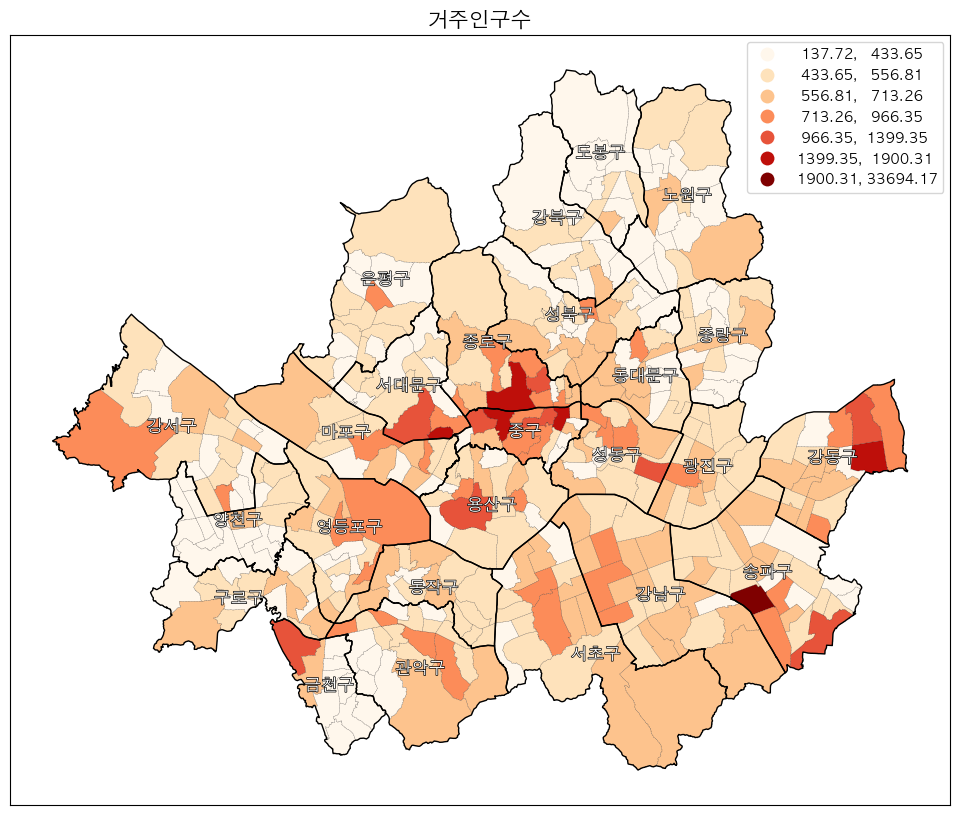

In [24]:
plt.rcParams['font.family'] = 'AppleGothic'
# 구 단위로 dissolve
# dissolve 전에 geometry 오류 정리
dongs['geometry'] = dongs['geometry'].buffer(0)
# dissolve
boroughs = dongs.dissolve(by='SIGUNGU_NM')
# dissolve 결과 geometry 오류 정리
boroughs['geometry'] = boroughs['geometry'].buffer(0.001)


fig, ax = plt.subplots(figsize=(15, 10))
dongs.plot(
    column='총생활인구수',
    ax=ax,
    legend=True,
    cmap='OrRd',
    scheme='natural_breaks',
    k=7)
dongs.boundary.plot(
    ax=ax,
    linestyle='dotted',
    lw=0.2,
    color='black',
    zorder=1
)
# # Your code here
# # 구 경계 진하게 추가
boroughs.boundary.plot(
    ax=ax,
    color='black',     # 원하는 색상(예: 'black', 'red', 'blue' 등)
    linestyle='-',
    lw=1,    # 경계선 두께(예: 2~4)
    zorder=2
)


for idx, row in boroughs.iterrows():
    ax.text(s=idx, # String to be displayed
                x=row['geometry'].centroid.coords[:][0][0], # X coordinate of label
                y=row['geometry'].centroid.coords[:][0][1], # Y coordinate of label
                fontsize=12, 
                color='white',
                path_effects=[pe.withStroke(linewidth=1, foreground="black")],
                ha='center', # Horizontal align
                va='center', # Vertical align
               )
ax.set_title(f'거주인구수', fontsize=15)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)


In [54]:
parks = parks.to_crs("epsg:4326")
dongs = dongs.to_crs("epsg:4326")
dongs_list = ['Seoul, South Korea']

# 2. UTM-K 좌표계로 임시 변환 (격자 생성용)
from pyproj import CRS
utm_zone = 52  # 서울 기준
parks_utm = parks.to_crs(CRS(f"EPSG:326{utm_zone}"))


G = ox.graph_from_place(dongs_list, network_type='walk')
G.remove_nodes_from(list(nx.isolates(G)))

In [60]:
from shapely.geometry import box
def create_polygon_grid(polygon, grid_size):
    """격자 생성 (미터 단위 좌표계 필수)"""
    # 경계 계산
    minx, miny, maxx, maxy = polygon.bounds
    
    # 격자 좌표 배열 (미터 단위)
    x_coords = np.arange(minx, maxx + grid_size, grid_size)
    y_coords = np.arange(miny, maxy + grid_size, grid_size)
    
    grids = []
    for x in x_coords[:-1]:  # 마지막 격자 제외
        for y in y_coords[:-1]:
            cell = box(x, y, x+grid_size, y+grid_size)
            if polygon.intersects(cell):
                intersection = polygon.intersection(cell)
                if not intersection.is_empty:
                    grids.append(intersection.centroid)
    return grids
    
def explode_grids(gdf, grid_size):
    """격자 분할 및 레코드 증식 (수정 버전)"""
    exploded = []
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom.is_empty or not geom.is_valid:
            continue
            
        # 폴리곤 처리
        if geom.geom_type in ['Polygon', 'MultiPolygon']:
            if geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    grids = create_polygon_grid(poly, grid_size)
                    for pt in grids:
                        new_row = row.copy()
                        new_row.geometry = pt
                        new_row['parent_id'] = idx  # parent_id 추가
                        exploded.append(new_row)
            else:
                grids = create_polygon_grid(geom, grid_size)
                for pt in grids:
                    new_row = row.copy()
                    new_row.geometry = pt
                    new_row['parent_id'] = idx  # parent_id 추가
                    exploded.append(new_row)
        else:
            # 점/선형 데이터 처리
            new_row = row.copy()
            new_row['parent_id'] = idx
            exploded.append(new_row)
    
    return gpd.GeoDataFrame(exploded, crs=gdf.crs)

# 적용
supply_utm = explode_grids(parks_utm, grid_size=200)

# 2. WGS84로 재변환 (OSMnx 호환)
supply_wgs84 = supply_utm.to_crs("EPSG:4326")



In [52]:
supply

,U2_COD,U2_NAM,Area,geometry,nearest_osm
0,110,도시숲,27.916095,POINT (127.07116 37.43063),7.168391e+09
1,110,도시숲,427.471653,POINT (127.07038 37.43065),7.168391e+09
2,110,도시숲,807.625803,POINT (127.07073 37.4309),7.168391e+09
3,110,도시숲,246.678781,POINT (127.07029 37.43108),7.168391e+09
4,110,도시숲,80.680325,POINT (127.06995 37.43105),7.168391e+09
...,...,...,...,...,...
155038,310,가로수,196.667732,POINT (127.04901 37.6916),9.122097e+09
155039,310,가로수,13.766157,POINT (127.04493 37.69227),1.023761e+10
155040,310,가로수,25.741987,POINT (127.04526 37.6923),1.023761e+10
155041,310,가로수,243.289499,POINT (127.04823 37.69297),8.823892e+09


In [66]:
supply_wgs84

,U2_COD,U2_NAM,Area,geometry,nearest_osm,parent_id
0,110,도시숲,27.916095,POINT (127.07116 37.43063),7.168391e+09,0
1,110,도시숲,427.471653,POINT (127.07038 37.43065),7.168391e+09,1
2,110,도시숲,807.625803,POINT (127.07073 37.4309),7.168391e+09,2
3,110,도시숲,246.678781,POINT (127.07029 37.43108),7.168391e+09,3
4,110,도시숲,80.680325,POINT (127.06995 37.43105),7.168391e+09,4
...,...,...,...,...,...,...
155038,310,가로수,196.667732,POINT (127.04901 37.6916),9.122097e+09,155038
155039,310,가로수,13.766157,POINT (127.04493 37.69227),1.023761e+10,155039
155040,310,가로수,25.741987,POINT (127.04526 37.6923),1.023761e+10,155040
155041,310,가로수,243.289499,POINT (127.04823 37.69297),8.823892e+09,155041


In [73]:
assert parks.crs == G.graph['crs'], "좌표계 불일치"


In [81]:
num_workers = min(8, os.cpu_count() - 1)  # 과도한 코어 사용 방지

In [82]:
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import numpy as np
import geopandas as gpd
import utils

def parallel_processing(network, gdf, grid_size=200, num_workers=None):
    num_workers = num_workers or (cpu_count() - 1)
    
    # 1. 청크 분할 + 타입 강제 지정
    chunks = [c.astype({'nearest_osm': 'object'}).reset_index(drop=True) 
              for c in np.array_split(gdf, num_workers)]
    
    args = [(network, chunk, grid_size) for chunk in chunks]
    
    with Pool(num_workers) as pool:
        results = list(tqdm(
            pool.starmap(utils.nearest_osm_enhanced, args),
            total=len(chunks),
            desc=f"Processing {len(gdf)} features"
        ))
    
    # 2. 최종 타입 통일
    final_gdf = gpd.GeoDataFrame(pd.concat(results), crs=gdf.crs)
    final_gdf['nearest_osm'] = final_gdf['nearest_osm'].astype('object')
    
    return final_gdf





if __name__ == "__main__":
    # 1. 초기 타입 설정
    supply_wgs84['nearest_osm'] = supply_wgs84['nearest_osm'].astype('object')
    
    # 2. 타입 확인
    assert supply_wgs84['nearest_osm'].dtype == 'object', "컬럼 타입 오류"
    supply = parallel_processing(
        network=G,
        gdf=supply_wgs84,
        grid_size=200,
        num_workers=8
    )
    
    # 결과 저장
    supply.to_file("result_final.geojson", driver='GeoJSON')


Processing 162407 features: 100%|█████████████| 8/8 [00:00<00:00, 190650.18it/s]


In [83]:
demand= utils.nearest_osm(G, dongs)

100%|█████████████████████████████████████████| 424/424 [01:04<00:00,  6.56it/s]


In [84]:
supply

,U2_COD,U2_NAM,Area,geometry,nearest_osm,parent_id
0,110,도시숲,27.916095,POINT (127.07116 37.43063),[7168390824],0
1,110,도시숲,427.471653,POINT (127.07038 37.43065),[7168390824],1
2,110,도시숲,807.625803,POINT (127.07073 37.4309),[7168390824],2
3,110,도시숲,246.678781,POINT (127.07029 37.43108),[7168390824],3
4,110,도시숲,80.680325,POINT (127.06995 37.43105),[7168390824],4
...,...,...,...,...,...,...
20295,310,가로수,196.667732,POINT (127.04901 37.6916),[9122097163],155038
20296,310,가로수,13.766157,POINT (127.04493 37.69227),[10237611266],155039
20297,310,가로수,25.741987,POINT (127.04526 37.6923),[10237611266],155040
20298,310,가로수,243.289499,POINT (127.04823 37.69297),[8823891955],155041


In [85]:
nodes, edges = ox.graph_to_gdfs(G, nodes = True, edges = True, node_geometry = True)

In [86]:
G = utils.network_settings_walk(G)

walk network set done


In [87]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True)

In [88]:
weights = {5:1, 10:0.68, 15:0.22}  # keys: time, values: weight


def step1_E2SFCA_alternative(
    weights,
    supply: gpd.GeoDataFrame,
    supply_attr: str,
    demand: gpd.GeoDataFrame,
    demand_attr: str,
    network: nx.MultiDiGraph
) -> gpd.GeoDataFrame:
    """
    개선된 1단계: 공원(parent_id) 단위 캐치먼트 통합 계산
    """
    supply_ = supply.copy(deep=True)
    supply_['ratio'] = 0

    # 공원별 그룹화
    for parent_id, group in tqdm(supply_.groupby('parent_id'), desc="Processing parks"):
        all_demand_nodes = set()
        
        # 모든 격자 노드의 캐치먼트 통합
        for idx, row in group.iterrows():
            nodes = row['nearest_osm']
            if isinstance(nodes, list):
                for node in nodes:
                    prev = set()
                    for time, _ in sorted(weights.items()):
                        temp = nx.single_source_dijkstra_path_length(
                            network, node, cutoff=time, weight='time'
                        ).keys()
                        all_demand_nodes.update(set(temp) - prev)
                        prev.update(temp)
            else:
                prev = set()
                for time, _ in sorted(weights.items()):
                    temp = nx.single_source_dijkstra_path_length(
                        network, nodes, cutoff=time, weight='time'
                    ).keys()
                    all_demand_nodes.update(set(temp) - prev)
                    prev.update(temp)

        # 고유 수요 계산
        total_demand = demand.loc[
            demand['nearest_osm'].isin(all_demand_nodes), demand_attr
        ].sum()

        # 비율 계산 및 할당
        ratio = (group[supply_attr].iloc[0] / total_demand * 100000) if total_demand > 0 else 0
        supply_.loc[group.index, 'ratio'] = ratio

    return supply_

result_step1 = step1_E2SFCA_alternative(weights, supply, 'Area', demand, '총생활인구수', G)

Processing parks: 100%|████████████████| 154395/154395 [16:49<00:00, 153.02it/s]


In [89]:
result_step1

,U2_COD,U2_NAM,Area,geometry,nearest_osm,parent_id,ratio
0,110,도시숲,27.916095,POINT (127.07116 37.43063),[7168390824],0,102918.680718
1,110,도시숲,427.471653,POINT (127.07038 37.43065),[7168390824],1,44180.549425
2,110,도시숲,807.625803,POINT (127.07073 37.4309),[7168390824],2,58947.136618
3,110,도시숲,246.678781,POINT (127.07029 37.43108),[7168390824],3,441.557436
4,110,도시숲,80.680325,POINT (127.06995 37.43105),[7168390824],4,2579.468525
...,...,...,...,...,...,...,...
20295,310,가로수,196.667732,POINT (127.04901 37.6916),[9122097163],155038,0.000000
20296,310,가로수,13.766157,POINT (127.04493 37.69227),[10237611266],155039,0.000000
20297,310,가로수,25.741987,POINT (127.04526 37.6923),[10237611266],155040,0.000000
20298,310,가로수,243.289499,POINT (127.04823 37.69297),[8823891955],155041,0.000000


In [90]:
def step2_E2SFCA_alternative(
    weights,
    result_step1: pd.DataFrame,
    demand: pd.DataFrame,
    network: nx.Graph
) -> pd.DataFrame:
    """
    개선된 2단계: 공원 단위 중복 제거 계산
    """
    # 공원별 데이터 사전 생성
    park_data = result_step1.groupby('parent_id').agg({
        'ratio': 'first',
        'nearest_osm': lambda x: list(set([n for lst in x for n in lst]))
    }).to_dict('index')

    demand_ = demand.copy()
    demand_['access'] = 0

    for z in tqdm(range(demand_.shape[0]), desc="Demand points"):
        total = 0
        prev = set()
        
        for time, weight in sorted(weights.items()):
            current = set(nx.single_source_dijkstra_path_length(
                network, demand_.loc[z, 'nearest_osm'], cutoff=time, weight='time'
            ).keys()) - prev
            
            # 공원별 접근성 확인
            for park_id, data in park_data.items():
                if any(node in current for node in data['nearest_osm']):
                    total += data['ratio'] * weight
            
            prev.update(current)
        
        demand_.loc[z, 'access'] = total

    return demand_


result_step2 = step2_E2SFCA_alternative(weights, result_step1, demand, G)

Demand points: 100%|██████████████████████████| 424/424 [00:34<00:00, 12.28it/s]


In [91]:
result_step2

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수,nearest_osm,access
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",646.165247,2.304578e+09,6.455338e+07
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",819.472895,4.198106e+09,4.503041e+06
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((126.96253 37.60575, 126.96246 37.605...",622.595385,4.368693e+08,5.067189e+06
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((126.97508 37.63118, 126.97468 37.629...",541.615290,2.303508e+09,9.892147e+06
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((126.96079 37.57378, 126.96074 37.573...",389.776531,3.096779e+09,1.598857e+07
...,...,...,...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((127.1448 37.51939, 127.14483 37.5192...",838.039244,1.245110e+10,4.397644e+06
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((127.15671 37.53758, 127.15654 37.537...",487.941971,5.273883e+09,6.338843e+06
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((127.13522 37.55473, 127.13569 37.554...",463.037580,4.194375e+09,1.696021e+07
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",696.772748,3.844539e+09,2.943332e+07


In [92]:
result_step2_nor = result_step2.copy(deep=True)


min_sum = result_step2_nor['access'].min()
max_sum = result_step2_nor['access'].max()
# if 문을 통해 반복을 돌린다. 이를 하지 않았더니 똑같은 값만 나왔었다.
if max_sum == min_sum:
    print('틀렸다')
else:
    result_step2_nor['access_normalized'] = (result_step2_nor['access'] - min_sum) / (max_sum - min_sum)

In [93]:
result_step2_nor

,SIDO_CD,SIDO_NM,SIGUNGU_CD,SIGUNGU_NM,ADM_CD,ADM_NM,geometry,총생활인구수,nearest_osm,access,access_normalized
0,11,서울특별시,11010,종로구,1101053,사직동,"POLYGON ((126.97399 37.57823, 126.974 37.57809...",646.165247,2.304578e+09,6.455338e+07,0.712191
1,11,서울특별시,11010,종로구,1101054,삼청동,"POLYGON ((126.97714 37.59768, 126.9773 37.5976...",819.472895,4.198106e+09,4.503041e+06,0.049680
2,11,서울특별시,11010,종로구,1101055,부암동,"POLYGON ((126.96253 37.60575, 126.96246 37.605...",622.595385,4.368693e+08,5.067189e+06,0.055904
3,11,서울특별시,11010,종로구,1101056,평창동,"POLYGON ((126.97508 37.63118, 126.97468 37.629...",541.615290,2.303508e+09,9.892147e+06,0.109136
4,11,서울특별시,11010,종로구,1101057,무악동,"POLYGON ((126.96079 37.57378, 126.96074 37.573...",389.776531,3.096779e+09,1.598857e+07,0.176395
...,...,...,...,...,...,...,...,...,...,...,...
419,11,서울특별시,11250,강동구,1125070,둔촌1동,"POLYGON ((127.1448 37.51939, 127.14483 37.5192...",838.039244,1.245110e+10,4.397644e+06,0.048517
420,11,서울특별시,11250,강동구,1125071,둔촌2동,"POLYGON ((127.15671 37.53758, 127.15654 37.537...",487.941971,5.273883e+09,6.338843e+06,0.069934
421,11,서울특별시,11250,강동구,1125072,암사1동,"POLYGON ((127.13522 37.55473, 127.13569 37.554...",463.037580,4.194375e+09,1.696021e+07,0.187115
422,11,서울특별시,11250,강동구,1125073,천호2동,"POLYGON ((127.11633 37.55005, 127.11642 37.550...",696.772748,3.844539e+09,2.943332e+07,0.324726


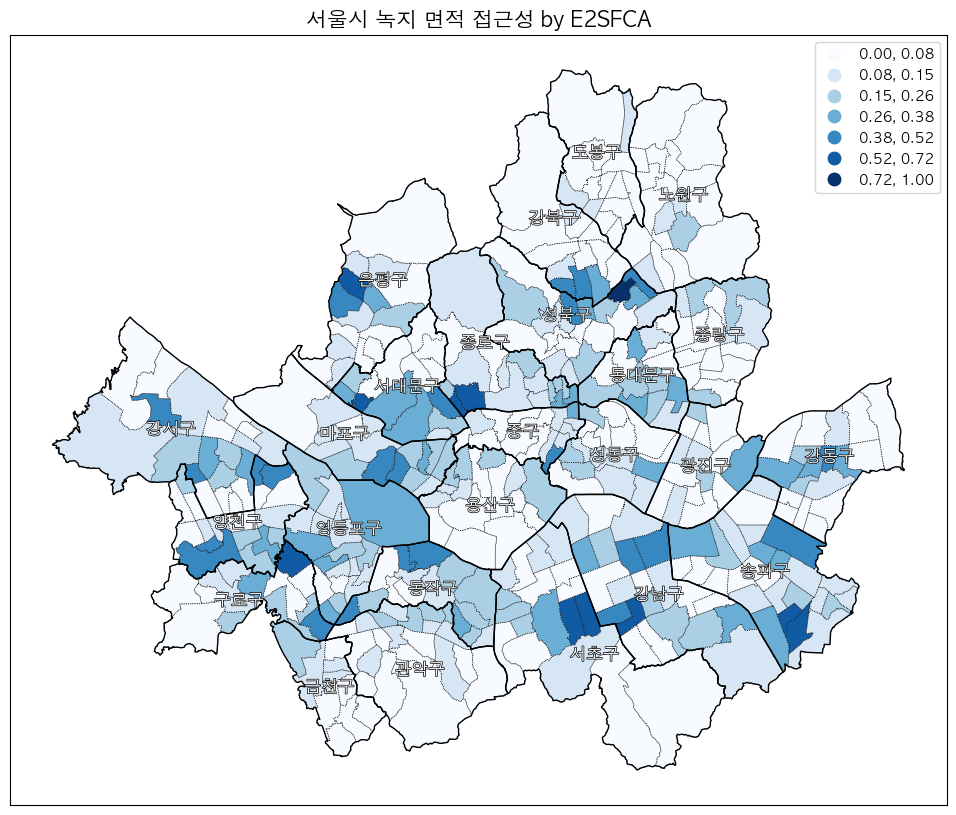

In [94]:
fig, ax = plt.subplots(figsize=(15, 10))

# 구 단위로 dissolve
# dissolve 전에 geometry 오류 정리
result_step2_nor['geometry'] = result_step2_nor['geometry'].buffer(0)
# dissolve
boroughs = result_step2_nor.dissolve(by='SIGUNGU_NM')

boroughs_1 = boroughs.copy()
boroughs_1 = boroughs_1.to_crs(epsg=5179)
boroughs_1['geometry'] = boroughs_1['geometry'].buffer(0.001)
boroughs_1 = boroughs_1.to_crs(epsg=4326)


# 첫 번째 지도: demand_
result_step2_nor.plot(
    column='access_normalized',
    ax=ax,
    legend=True,
    cmap='Blues',
    scheme='naturalbreaks',
    k=7
)
result_step2_nor.boundary.plot(
    ax=ax,
    linestyle='dotted',
    lw=0.5,
    color='black',
    zorder=1
)

boroughs_1.boundary.plot(
    ax=ax,
    color='black',     # 원하는 색상(예: 'black', 'red', 'blue' 등)
    linestyle='-',
    lw=1,    # 경계선 두께(예: 2~4)
    zorder=2
)
for idx, row in boroughs_1.iterrows():
    ax.text(s=idx, # String to be displayed
                x=row['geometry'].centroid.coords[:][0][0], # X coordinate of label
                y=row['geometry'].centroid.coords[:][0][1], # Y coordinate of label
                fontsize=12, 
                color='white',
                path_effects=[pe.withStroke(linewidth=1, foreground="black")],
                ha='center', # Horizontal align
                va='center', # Vertical align
               )
ax.set_title(f'서울시 녹지 면적 접근성 by E2SFCA', fontsize=15)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
# scalebar = ScaleBar(dx=1, units="m", location='lower right')  # dx=1은 좌표계가 미터 단위일 때
# ax.add_artist(scalebar)

In [95]:
dongs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   SIDO_CD      424 non-null    object  
 1   SIDO_NM      424 non-null    object  
 2   SIGUNGU_CD   424 non-null    object  
 3   SIGUNGU_NM   424 non-null    object  
 4   ADM_CD       424 non-null    object  
 5   ADM_NM       424 non-null    object  
 6   geometry     424 non-null    geometry
 7   총생활인구수       424 non-null    float64 
 8   nearest_osm  424 non-null    float64 
dtypes: float64(2), geometry(1), object(6)
memory usage: 29.9+ KB


In [96]:
dongs['총생활인구수'].describe()

count      424.000000
mean       619.669536
std       1624.237038
min        137.723546
25%        407.831778
50%        496.043481
75%        600.462766
max      33694.172275
Name: 총생활인구수, dtype: float64

In [97]:
max_idx = dongs['총생활인구수'].idxmax()
dongs.loc[max_idx]

SIDO_CD                                                       11
SIDO_NM                                                    서울특별시
SIGUNGU_CD                                                 11240
SIGUNGU_NM                                                   송파구
ADM_CD                                                   1124066
ADM_NM                                                      가락1동
geometry       POLYGON ((127.1101515247529 37.50051059492555,...
총생활인구수                                              33694.172275
nearest_osm                                         2911195456.0
Name: 394, dtype: object

In [98]:
min_idx = dongs['총생활인구수'].idxmin()
dongs.loc[min_idx]

SIDO_CD                                                       11
SIDO_NM                                                    서울특별시
SIGUNGU_CD                                                 11220
SIGUNGU_NM                                                   서초구
ADM_CD                                                   1122056
ADM_NM                                                      반포본동
geometry       POLYGON ((126.99222812629364 37.50663133440654...
총생활인구수                                                137.723546
nearest_osm                                        10124068123.0
Name: 344, dtype: object

In [99]:
result_step2_nor.to_file("./최종1_그리드_녹지면적접근성분석_도보.shp", driver="ESRI Shapefile")


In [101]:
result_step2_nor.to_file("./최종1_녹지면적접근성분석_도보.gpkg", driver="GPKG")



In [100]:
result_step2_nor.to_csv("./최종1_녹지면적접근성분석_도보.csv", encoding="utf-8", index=False)


In [115]:
print(type(supply))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [116]:
supply.to_file(
    "supply_data.gpkg", 
    driver="GPKG",
    layer="parks_supply",  # 레이어 이름 지정
    encoding="utf-8"
)
